# Interactive Session Smoke Test (Extended)
Notebook này test kỹ hơn các tính năng của `InteractiveSignalSession` và `SignalBasedPortfolio`:
- Open từ signal và open manual
- Update SL/TP
- Partial close + full close
- Kiểm tra history/actions/events/snapshot markers
- Save engine -> load engine -> so khớp dữ liệu
- Vẽ snapshot bằng `plot_signal`

> Mục tiêu: kiểm tra nhanh tính đúng đắn trước khi tích hợp vào TUI.

In [1]:
from datetime import datetime
from pathlib import Path
from pprint import pprint

import pandas as pd

from vnstock_forecast.builtin.signal_based.interactive.session import InteractiveSignalSession
from vnstock_forecast.builtin.signal_based.interactive.signal_based_portfolio import PositionStatus
from vnstock_forecast.builtin.signal_based.signal import Signal, SignalDirection, TradePlan
from vnstock_forecast.builtin.signal_based.visualization import plot_signal
from vnstock_forecast.builtin.signal_based.visualization.snapshot import SignalSnapshot
from vnstock_forecast.engine.data.query import query_grouped_ohlcv

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

TEST_DIR = Path("outputs/interactive/notebook-smoke-extended")
TEST_DIR.mkdir(parents=True, exist_ok=True)

session = InteractiveSignalSession(base_dir=TEST_DIR)

def print_header(title: str):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def summarize_position(pos):
    return {
        "position_id": pos.id,
        "symbol": pos.symbol,
        "status": pos.status.value,
        "entry_price": pos.entry_price,
        "initial_qty": pos.initial_quantity,
        "open_qty": pos.open_quantity,
        "signal_id": pos.signal_id,
        "stop_loss": pos.stop_loss,
        "take_profit": pos.take_profit,
        "entry_time": pos.entry_time.isoformat(),
    }

print_header("Session Initialized")
print(f"Base dir: {TEST_DIR.resolve()}")
print(f"Initial cash: {session.live_engine.portfolio.initial_cash:,.0f}")


Session Initialized
Base dir: /mnt/data/QuickAccess/Documents/4.Tin/Projects/vnstock-forecast/notebooks/test/outputs/interactive/notebook-smoke-extended
Initial cash: 100,000,000


In [7]:
print_header("Scenario 1 - Open from BUY Signal + Update Risk")

buy_dt_vcb = datetime(2026, 3, 14, 9, 30)
risk_update_dt = datetime(2026, 3, 17, 9, 30)

# Lấy giá nền từ dữ liệu thật để chart trực quan hơn
vcb_probe = query_grouped_ohlcv(
    symbols=["VCB"],
    resolutions=["D"],
    to_ts=int(datetime.now().timestamp()),
    lookback_bars=30,
).get("D", {}).get("VCB", pd.DataFrame())

vcb_market_base = float(vcb_probe.iloc[-1]["Close"]) if not vcb_probe.empty else 60000.0
vcb_entry = round(vcb_market_base * 0.98, 2)
vcb_stop = round(vcb_entry * 0.96, 2)
vcb_tp = round(vcb_entry * 1.08, 2)

buy_signal_vcb = Signal(
    technique="SMOKE_BUY_VCB",
    symbol="VCB",
    direction=SignalDirection.BUY,
    timestamp=buy_dt_vcb,
    trade_plan=TradePlan(entry=vcb_entry, stop_loss=vcb_stop, take_profit=vcb_tp),
    confidence=0.91,
    reason="Notebook extended smoke buy VCB",
)

session._build_current_prices = lambda symbols, resolution, timestamp: {s: vcb_entry for s in symbols}

buy_result_vcb = session.order_buy(
    symbol="VCB",
    quantity=100,
    signal=buy_signal_vcb,
    timestamp=buy_dt_vcb,
    primary_resolution="D",
)

open_positions = session.list_positions(status=PositionStatus.OPEN)
assert len(open_positions) == 1, f"Expected 1 open position, got {len(open_positions)}"
vcb_pos = open_positions[0]
vcb_position_id = vcb_pos.id

print("Buy result events:")
for ev in buy_result_vcb.events:
    print(vars(ev))

print("\nOpen position summary:")
pprint(summarize_position(vcb_pos))

snapshot_vcb = session.get_snapshot(vcb_position_id)
assert snapshot_vcb.entry == vcb_entry
assert snapshot_vcb.stop_loss == vcb_stop
assert snapshot_vcb.take_profit == vcb_tp
assert len(snapshot_vcb.buy_markers) == 1
assert len(snapshot_vcb.sell_markers) == 0

updated_sl = round(vcb_entry * 0.97, 2)
updated_tp = round(vcb_entry * 1.12, 2)

session.update_position_risk(
    position_id=vcb_position_id,
    stop_loss=updated_sl,
    take_profit=updated_tp,
    timestamp=risk_update_dt,
    note="raise SL and TP for smoke test",
)

snapshot_vcb = session.get_snapshot(vcb_position_id)
assert snapshot_vcb.stop_loss == updated_sl
assert snapshot_vcb.take_profit == updated_tp

print("\nSnapshot after risk update:")
print({
    "snapshot_id": snapshot_vcb.snapshot_id,
    "buy_markers": len(snapshot_vcb.buy_markers),
    "sell_markers": len(snapshot_vcb.sell_markers),
    "stop_loss": snapshot_vcb.stop_loss,
    "take_profit": snapshot_vcb.take_profit,
})


Scenario 1 - Open from BUY Signal + Update Risk
Buy result events:
{'timestamp': datetime.datetime(2026, 3, 14, 9, 30), 'action': 'buy', 'symbol': 'VCB', 'price': 56840.0, 'quantity': 100, 'position_id': '1acb083e', 'equity': 99991474.0, 'reason': 'Notebook extended smoke buy VCB'}

Open position summary:
{'entry_price': 56840.0,
 'entry_time': '2026-03-14T09:30:00',
 'initial_qty': 100.0,
 'open_qty': 100.0,
 'position_id': '1acb083e',
 'signal_id': '2c896a94a443',
 'status': 'open',
 'stop_loss': 54566.4,
 'symbol': 'VCB',
 'take_profit': 61387.2}

Snapshot after risk update:
{'snapshot_id': '5e0eb60f1dcd', 'buy_markers': 1, 'sell_markers': 0, 'stop_loss': 55134.8, 'take_profit': 63660.8}


In [8]:
print_header("Scenario 2 - Manual Open + Partial/Full Close + History Validation")

# 2.1 Manual open on SSI với giá thực tế
ssi_probe = query_grouped_ohlcv(
    symbols=["SSI"],
    resolutions=["D"],
    to_ts=int(datetime.now().timestamp()),
    lookback_bars=30,
).get("D", {}).get("SSI", pd.DataFrame())

ssi_market_base = float(ssi_probe.iloc[-1]["Close"]) if not ssi_probe.empty else 28000.0
ssi_entry = round(ssi_market_base * 0.99, 2)
ssi_sl = round(ssi_entry * 0.95, 2)
ssi_tp = round(ssi_entry * 1.10, 2)

open_manual_dt = datetime(2026, 3, 14, 10, 0)
session._build_current_prices = lambda symbols, resolution, timestamp: {s: ssi_entry for s in symbols}
manual_open_result = session.order_buy(
    symbol="SSI",
    quantity=200,
    signal=None,
    timestamp=open_manual_dt,
    price=ssi_entry,
    stop_loss=ssi_sl,
    take_profit=ssi_tp,
    reason="manual open SSI",
)

ssi_open_positions = [p for p in session.list_positions(status=PositionStatus.OPEN) if p.symbol == "SSI"]
assert len(ssi_open_positions) == 1
ssi_position_id = ssi_open_positions[0].id

print("Manual open event:")
for ev in manual_open_result.events:
    print(vars(ev))

# 2.2 Partial close VCB
partial_close_dt = datetime(2026, 3, 20, 10, 15)
sell_signal_vcb = Signal(
    technique="SMOKE_SELL_VCB",
    symbol="VCB",
    direction=SignalDirection.SELL,
    timestamp=partial_close_dt,
    confidence=0.84,
    reason="partial close VCB",
)
vcb_partial_exit = round(vcb_entry * 1.02, 2)
session._build_current_prices = lambda symbols, resolution, timestamp: {s: vcb_partial_exit for s in symbols}
partial_close_result = session.order_sell(
    symbol="VCB",
    position_id=vcb_position_id,
    quantity=40,
    signal=sell_signal_vcb,
    timestamp=partial_close_dt,
    primary_resolution="D",
)

# 2.3 Full close remaining VCB
full_close_dt = datetime(2026, 3, 20, 14, 30)
vcb_full_exit = round(vcb_entry * 1.04, 2)
session._build_current_prices = lambda symbols, resolution, timestamp: {s: vcb_full_exit for s in symbols}
full_close_result = session.order_sell(
    symbol="VCB",
    position_id=vcb_position_id,
    signal=sell_signal_vcb,
    timestamp=full_close_dt,
    primary_resolution="D",
)

# 2.4 Full close SSI manual
full_close_ssi_dt = datetime(2026, 3, 20, 14, 45)
ssi_exit = round(ssi_entry * 1.03, 2)
session._build_current_prices = lambda symbols, resolution, timestamp: {s: ssi_exit for s in symbols}
full_close_ssi_result = session.order_sell(
    symbol="SSI",
    position_id=ssi_position_id,
    signal=None,
    timestamp=full_close_ssi_dt,
    price=ssi_exit,
    reason="manual close SSI",
)

print("Partial close events:")
for ev in partial_close_result.events:
    print(vars(ev))

print("\nFull close VCB events:")
for ev in full_close_result.events:
    print(vars(ev))

print("\nFull close SSI events:")
for ev in full_close_ssi_result.events:
    print(vars(ev))

open_after = session.list_positions(status=PositionStatus.OPEN)
closed_after = session.list_positions(status=PositionStatus.CLOSED)
assert len(open_after) == 0, f"Expected no open positions, got {len(open_after)}"
assert len(closed_after) >= 3, f"Expected >=3 closed legs, got {len(closed_after)}"

snapshot_vcb = session.get_snapshot(vcb_position_id)
assert len(snapshot_vcb.buy_markers) == 1
assert len(snapshot_vcb.sell_markers) == 2
assert snapshot_vcb.sell_markers[0].quantity == 40

snapshot_ssi = session.get_snapshot(ssi_position_id)
assert len(snapshot_ssi.buy_markers) == 1
assert len(snapshot_ssi.sell_markers) == 1

actions_vcb = session.list_actions(position_id=vcb_position_id)
actions_ssi = session.list_actions(position_id=ssi_position_id)
assert len(actions_vcb) >= 4, f"Expected >=4 actions for VCB, got {len(actions_vcb)}"
assert len(actions_ssi) >= 2, f"Expected >=2 actions for SSI, got {len(actions_ssi)}"

print("\nAction history VCB:")
display(pd.DataFrame([
    {
        "action_id": a.action_id,
        "type": a.action_type.value,
        "symbol": a.symbol,
        "qty": a.quantity,
        "price": a.price,
        "signal_id": a.signal_id,
        "timestamp": a.timestamp,
        "note": a.note,
    }
    for a in actions_vcb
]).sort_values("timestamp"))

print("\nAction history SSI:")
display(pd.DataFrame([
    {
        "action_id": a.action_id,
        "type": a.action_type.value,
        "symbol": a.symbol,
        "qty": a.quantity,
        "price": a.price,
        "signal_id": a.signal_id,
        "timestamp": a.timestamp,
        "note": a.note,
    }
    for a in actions_ssi
]).sort_values("timestamp"))

print("\nEngine event log tail:")
display(pd.DataFrame([vars(e) for e in session.live_engine.events]).tail(10))


Scenario 2 - Manual Open + Partial/Full Close + History Validation
Manual open event:
{'timestamp': datetime.datetime(2026, 3, 14, 10, 0), 'action': 'buy', 'symbol': 'SSI', 'price': 26680.5, 'quantity': 200, 'position_id': '665a5130', 'equity': 99983469.85, 'reason': 'manual open SSI'}
Partial close events:
{'timestamp': datetime.datetime(2026, 3, 20, 10, 15), 'action': 'sell', 'symbol': 'VCB', 'price': 57976.8, 'quantity': 40.0, 'position_id': '1acb083e', 'equity': 100093671.242, 'reason': 'partial close VCB'}

Full close VCB events:
{'timestamp': datetime.datetime(2026, 3, 20, 14, 30), 'action': 'sell', 'symbol': 'VCB', 'price': 59113.6, 'quantity': 60.0, 'position_id': '1acb083e', 'equity': 100156559.01799999, 'reason': 'partial close VCB'}

Full close SSI events:
{'timestamp': datetime.datetime(2026, 3, 20, 14, 45), 'action': 'sell', 'symbol': 'SSI', 'price': 27480.92, 'quantity': 200.0, 'position_id': '665a5130', 'equity': 100308398.742, 'reason': 'manual close SSI'}

Action hist

,action_id,type,symbol,qty,price,signal_id,timestamp,note
0,391ef95928db,buy,VCB,100.0,56840.0,2c896a94a443,2026-03-14 09:30:00,Notebook extended smoke buy VCB
1,861f0013da6e,update_risk,VCB,0.0,56840.0,manual-fb19d942b49c,2026-03-17 09:30:00,raise SL and TP for smoke test
2,0b09381277c5,sell,VCB,40.0,57976.8,04c6adfc86f4,2026-03-20 10:15:00,partial close VCB
3,adae34e68481,sell,VCB,60.0,59113.6,04c6adfc86f4,2026-03-20 14:30:00,partial close VCB



Action history SSI:


,action_id,type,symbol,qty,price,signal_id,timestamp,note
0,1b032ac542a4,buy,SSI,200.0,26680.50,manual-f8fcd58449b1,2026-03-14 10:00:00,manual open SSI
1,65a6338a2e2c,sell,SSI,200.0,27480.92,manual-1c2feeea200d,2026-03-20 14:45:00,manual close SSI



Engine event log tail:


,timestamp,action,symbol,price,quantity,position_id,equity,reason
0,2026-03-14 09:30:00,buy,VCB,56840.00,100.0,1acb083e,9.999147e+07,Notebook extended smoke buy VCB
1,2026-03-17 09:30:00,update_risk,VCB,56840.00,0.0,1acb083e,9.999147e+07,raise SL and TP for smoke test
2,2026-03-14 10:00:00,buy,SSI,26680.50,200.0,665a5130,9.998347e+07,manual open SSI
3,2026-03-20 10:15:00,sell,VCB,57976.80,40.0,1acb083e,1.000937e+08,partial close VCB
4,2026-03-20 14:30:00,sell,VCB,59113.60,60.0,1acb083e,1.001566e+08,partial close VCB
5,2026-03-20 14:45:00,sell,SSI,27480.92,200.0,665a5130,1.003084e+08,manual close SSI


In [9]:
print_header("Scenario 3 - Save/Load Engine + Consistency Checks")

engine_path = TEST_DIR / "engine_state_smoke_extended.pkl"
saved_path = session.save_engine(engine_path)
assert saved_path.exists(), f"Engine state not found at {saved_path}"

reloaded_session = InteractiveSignalSession(base_dir=TEST_DIR / "reloaded")
reloaded_engine = reloaded_session.load_engine(engine_path)

print(f"Saved engine path: {saved_path}")
print(f"Reloaded engine type: {type(reloaded_engine).__name__}")

# Core consistency checks
reloaded_actions_vcb = reloaded_session.list_actions(position_id=vcb_position_id)
reloaded_actions_ssi = reloaded_session.list_actions(position_id=ssi_position_id)
reloaded_snapshot_vcb = reloaded_session.get_snapshot(vcb_position_id)
reloaded_snapshot_ssi = reloaded_session.get_snapshot(ssi_position_id)
reloaded_closed_positions = reloaded_session.list_positions(status=PositionStatus.CLOSED)

assert len(reloaded_actions_vcb) == len(actions_vcb)
assert len(reloaded_actions_ssi) == len(actions_ssi)
assert len(reloaded_snapshot_vcb.buy_markers) == len(snapshot_vcb.buy_markers)
assert len(reloaded_snapshot_vcb.sell_markers) == len(snapshot_vcb.sell_markers)
assert len(reloaded_snapshot_ssi.buy_markers) == len(snapshot_ssi.buy_markers)
assert len(reloaded_snapshot_ssi.sell_markers) == len(snapshot_ssi.sell_markers)
assert len(reloaded_closed_positions) == len(closed_after)

consistency_report = {
    "saved_path": str(saved_path),
    "events_count": len(reloaded_session.live_engine.events),
    "closed_positions": len(reloaded_closed_positions),
    "vcb_actions": len(reloaded_actions_vcb),
    "ssi_actions": len(reloaded_actions_ssi),
    "vcb_markers": {
        "buy": len(reloaded_snapshot_vcb.buy_markers),
        "sell": len(reloaded_snapshot_vcb.sell_markers),
    },
    "ssi_markers": {
        "buy": len(reloaded_snapshot_ssi.buy_markers),
        "sell": len(reloaded_snapshot_ssi.sell_markers),
    },
}
pprint(consistency_report)


Scenario 3 - Save/Load Engine + Consistency Checks
Saved engine path: outputs/interactive/notebook-smoke-extended/engine_state_smoke_extended.pkl
Reloaded engine type: InteractiveEngine
{'closed_positions': 3,
 'events_count': 6,
 'saved_path': 'outputs/interactive/notebook-smoke-extended/engine_state_smoke_extended.pkl',
 'ssi_actions': 2,
 'ssi_markers': {'buy': 1, 'sell': 1},
 'vcb_actions': 4,
 'vcb_markers': {'buy': 1, 'sell': 2}}



Scenario 4 - Plot Snapshot via plot_signal
{'plotted_symbol': 'VCB', 'position_id': '1acb083e', 'buy_markers': 1, 'sell_markers': 2, 'ohlcv_rows_used': 81}


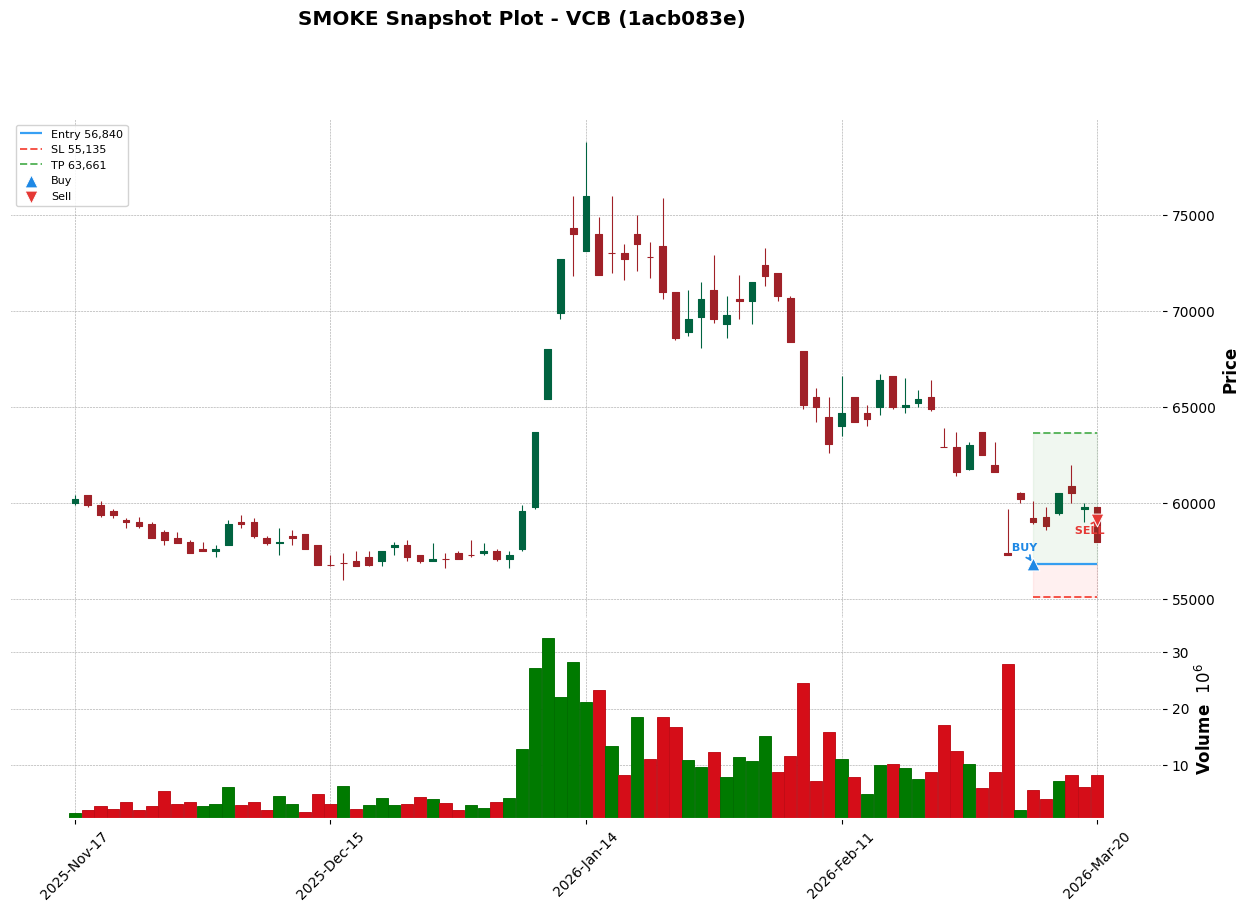

In [ ]:
print_header("Scenario 4 - Plot Snapshot via plot_signal")

plot_snapshot = reloaded_session.build_plot_snapshot(reloaded_snapshot_vcb.position_id)
fig = plot_signal(
    plot_snapshot,
    extend_bars=0,
    title=f"SMOKE Snapshot Plot - {reloaded_snapshot_vcb.symbol} ({reloaded_snapshot_vcb.position_id})",
    show=False,
)

print({
    "plotted_symbol": reloaded_snapshot_vcb.symbol,
    "position_id": reloaded_snapshot_vcb.position_id,
    "buy_markers": len(reloaded_snapshot_vcb.buy_markers),
    "sell_markers": len(reloaded_snapshot_vcb.sell_markers),
    "indicator_count": len(plot_snapshot.indicators),
    "ohlcv_rows_used": len(plot_snapshot.ohlcv),
})



Scenario 5 - Real Technique (06/2025 -> 01/2026) -> Pick Signal -> Buy -> Sell after 15 days -> Plot
Technique: sma_short_crossover
Total signals: 27
BUY signals: 14
Selected signal:
{'signal_id': '0c21960b4d2e', 'symbol': 'SSI', 'timestamp': datetime.datetime(2025, 6, 23, 0, 0), 'confidence': 0.5031733440289969, 'reason': 'SMA(10)=21033 cắt lên SMA(30)=21029 | gap=0.02% slope=0.169%', 'signal_snapshot_indicators': 2}

Buy execution events:
{'timestamp': datetime.datetime(2025, 6, 23, 0, 0), 'action': 'buy', 'symbol': 'SSI', 'price': 21113.25125, 'quantity': 100, 'position_id': '47c945e5', 'equity': 100722806.600425, 'reason': 'SMA(10)=21033 cắt lên SMA(30)=21029 | gap=0.02% slope=0.169%'}

New position summary:
{'entry_price': 21113.25125,
 'entry_time': '2025-06-23T00:00:00',
 'initial_qty': 100.0,
 'open_qty': 100.0,
 'position_id': '47c945e5',
 'signal_id': '0c21960b4d2e',
 'status': 'open',
 'stop_loss': 20409.48,
 'symbol': 'SSI',
 'take_profit': 23224.58}
Snapshot markers after

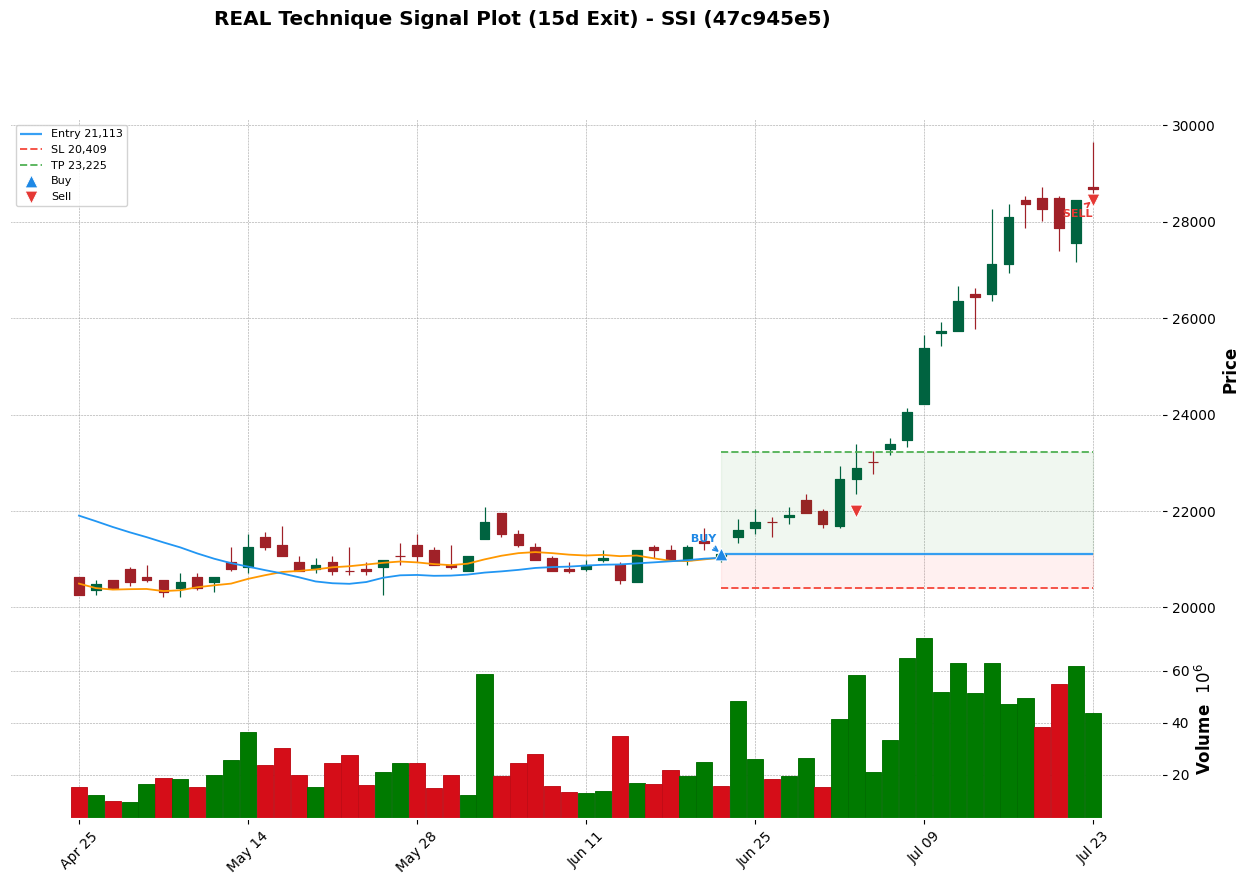

In [4]:
print_header("Scenario 5 - Real Technique (06/2025 -> 01/2026) -> Pick Signal -> Buy -> Sell after 15 days -> Plot")

from datetime import timedelta
from vnstock_forecast.builtin.signal_based.registry import get_technique

# 1) Load technique thật từ registry
TechniqueCls = get_technique("sma_short_crossover")
technique = TechniqueCls()

# 2) Query signals trong khoảng thời gian yêu cầu
from_ts_real = int(datetime(2025, 6, 1, 0, 0).timestamp())
to_ts_real = int(datetime(2026, 1, 31, 23, 59).timestamp())
symbols_to_scan = ["VCB", "SSI", "FPT", "HPG", "MWG"]

real_signals = session.get_signal(
    techniques=[technique],
    symbols=symbols_to_scan,
    from_ts=from_ts_real,
    to_ts=to_ts_real,
    resolutions=["D"],
    min_confidence=0.0,
    attach_snapshot=True,
    snapshot_lookback=200,
)

buy_signals = [s for s in real_signals if s.direction == SignalDirection.BUY]
assert buy_signals, "Không tìm thấy BUY signal trong giai đoạn test"

selected_signal = sorted(buy_signals, key=lambda s: s.timestamp)[0]

print("Technique:", technique.name)
print("Total signals:", len(real_signals))
print("BUY signals:", len(buy_signals))
print("Selected signal:")
print({
    "signal_id": selected_signal.signal_id,
    "symbol": selected_signal.symbol,
    "timestamp": selected_signal.timestamp,
    "confidence": selected_signal.confidence,
    "reason": selected_signal.reason,
    "signal_snapshot_indicators": len(selected_signal.snapshot.indicators) if selected_signal.snapshot is not None else 0,
})

# 3) Buy order từ signal đã chọn
qty = 100
signal_entry_price = (
    float(selected_signal.trade_plan.entry)
    if selected_signal.trade_plan is not None
    else None
)

if signal_entry_price is None:
    probe_df = query_grouped_ohlcv(
        symbols=[selected_signal.symbol],
        resolutions=["D"],
        to_ts=int(selected_signal.timestamp.timestamp()),
        lookback_bars=1,
    ).get("D", {}).get(selected_signal.symbol, pd.DataFrame())
    signal_entry_price = float(probe_df.iloc[-1]["Close"]) if not probe_df.empty else 10000.0

session._build_current_prices = lambda symbols, resolution, timestamp: {
    s: signal_entry_price for s in symbols
}

buy_real_result = session.order_buy(
    symbol=selected_signal.symbol,
    quantity=qty,
    signal=selected_signal,
    timestamp=selected_signal.timestamp,
    primary_resolution="D",
)

print("\nBuy execution events:")
for ev in buy_real_result.events:
    print(vars(ev))

# 4) Lấy position mới mở tương ứng signal
open_positions_now = session.list_positions(symbol=selected_signal.symbol, status=PositionStatus.OPEN)
assert open_positions_now, "Không tìm thấy position mở sau khi buy"

signal_positions = [p for p in open_positions_now if p.signal_id == selected_signal.signal_id]
new_position = signal_positions[-1] if signal_positions else open_positions_now[-1]
new_position_id = new_position.id

new_snapshot = session.get_snapshot(new_position_id)
assert len(new_snapshot.buy_markers) >= 1

print("\nNew position summary:")
pprint(summarize_position(new_position))
print(
    "Snapshot markers after BUY:",
    {
        "buy": len(new_snapshot.buy_markers),
        "sell": len(new_snapshot.sell_markers),
        "indicators": len(new_snapshot.indicators),
        "hlines": len(new_snapshot.hlines),
        "vlines": len(new_snapshot.vlines),
        "rectangles": len(new_snapshot.rectangles),
        "trendlines": len(new_snapshot.trendlines),
    },
)

# 5) SELL sau 15 ngày kể từ signal
sell_dt_1 = selected_signal.timestamp + timedelta(days=10)
sell_dt_all = selected_signal.timestamp + timedelta(days=30)

sell_probe_df = query_grouped_ohlcv(
    symbols=[selected_signal.symbol],
    resolutions=["D"],
    to_ts=int(sell_dt_all.timestamp()),
    lookback_bars=1,
).get("D", {}).get(selected_signal.symbol, pd.DataFrame())

sell_price = float(sell_probe_df.iloc[-1]["Close"]) if not sell_probe_df.empty else signal_entry_price * 1.01

sell_signal = Signal(
    technique=f"{selected_signal.technique}_exit_15d",
    symbol=selected_signal.symbol,
    direction=SignalDirection.SELL,
    timestamp=sell_dt_all,
    confidence=selected_signal.confidence,
    reason="Exit after 15 days from BUY signal",
)

session._build_current_prices = lambda symbols, resolution, timestamp: {
    s: sell_price for s in symbols
}

sell_real_result_1 = session.order_sell(
    symbol=selected_signal.symbol,
    position_id=new_position_id,
    timestamp=sell_dt_1,
    primary_resolution="D",
    quantity=10,
    price=22000
)

sell_real_result = session.order_sell(
    symbol=selected_signal.symbol,
    position_id=new_position_id,
    signal=sell_signal,
    timestamp=sell_dt_all,
    primary_resolution="D",
)

print("\nSell execution events (15d):")
for ev in sell_real_result.events:
    print(vars(ev))

new_snapshot = session.get_snapshot(new_position_id)
print(
    "Snapshot markers after SELL:",
    {
        "buy": len(new_snapshot.buy_markers),
        "sell": len(new_snapshot.sell_markers),
    },
)
assert len(new_snapshot.sell_markers) >= 1, "Expected at least 1 sell marker after 15-day exit"

# 6) Build SignalSnapshot từ session API để plot
plot_snapshot_real = session.build_plot_snapshot(new_position_id, to_ts=sell_dt_all)
fig_real = plot_signal(
    plot_snapshot_real,
    extend_bars=0,
    title=f"REAL Technique Signal Plot (15d Exit) - {new_snapshot.symbol} ({new_snapshot.position_id})",
    show=False,
)

print("\nPlot ready:")
print({
    "symbol": new_snapshot.symbol,
    "position_id": new_snapshot.position_id,
    "entry": new_snapshot.entry,
    "sl": new_snapshot.stop_loss,
    "tp": new_snapshot.take_profit,
    "indicator_count": len(plot_snapshot_real.indicators),
    "ohlcv_rows": len(plot_snapshot_real.ohlcv),
    "sell_dt": sell_dt_all,
    "sell_price": sell_price,
})
